# **Olist E-Commerce Analytics: Customer Orders, Payment Behavior, and Delivery Performance Analysis**

## **End-to-End Exploratory Data Analysis using Python, SQL, and Power BI**


**Developed By :** Arragudla Tejeendra

**Tools & Technologies :**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
- SQL
- Power BI

### **Executive Summary**

This project analyzes the Olist Brazilian E-Commerce dataset to uncover operational, customer, and transactional insights across the marketplace ecosystem.

The analysis focuses on:

- Order growth trends
- Customer purchasing behavior
- Payment preferences
- Installment usage patterns
- Logistics and delivery performance
- Fulfillment efficiency

Using Python-based exploratory data analysis techniques, the project identifies operational patterns and business opportunities that can support strategic decision-making in e-commerce operations.

Key business findings include:

- Strong marketplace growth during 2017–2018
- Heavy dependency on credit card transactions
- High preference for low-installment purchases
- Efficient delivery operations with most orders arriving before estimated dates
- Relatively low late-delivery frequency indicating strong logistics performance

## **Business Objective**

### Business Problem Statement

E-commerce platforms operate across multiple business functions including payments, logistics, fulfillment, and customer experience.

Understanding transaction behavior and operational efficiency is critical for:

- improving customer satisfaction
- reducing delivery delays
- optimizing payment strategies
- supporting operational scalability
- identifying marketplace growth trends

This analysis aims to evaluate how Olist performs across these operational dimensions using transactional and logistics data.

## **Dataset Overview**

### Dataset Description

The analysis uses multiple relational datasets from the Olist marketplace ecosystem, including:

- Orders dataset
- Customers dataset
- Order items dataset
- Products dataset
- Payments dataset
- Product category translation dataset

These datasets collectively provide visibility into:

- customer activity
- purchasing behavior
- transaction methods
- delivery timelines
- operational performance

## **Environment Setup & Library Imports**

The analysis environment was configured using Python libraries commonly used in data analytics and visualization workflows.

The following libraries were used for:
- data manipulation and transformation
- numerical computation
- visualization and plotting
- datetime handling
- exploratory data analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)

## **Data Loading & Initial Validation**

### Data Loading

The Olist E-Commerce datasets were imported into the Python environment using Pandas. Multiple relational tables including orders, customers, products, payments, and translations were loaded to support end-to-end business analysis.

These datasets collectively provide insights into:
- Customer purchasing behavior
- Revenue trends
- Product performance
- Payment preferences
- Delivery efficiency
- Regional sales distribution

In [2]:
orders = pd.read_csv("C:/Users/tejee/OneDrive/Desktop/Data_Analytics_Projects/Olist_Ecommerce_Project/raw_data/olist_orders_dataset.csv")

customers = pd.read_csv("C:/Users/tejee/OneDrive/Desktop/Data_Analytics_Projects/Olist_Ecommerce_Project/raw_data/olist_customers_dataset.csv")

order_items = pd.read_csv("C:/Users/tejee/OneDrive/Desktop/Data_Analytics_Projects/Olist_Ecommerce_Project/raw_data/olist_order_items_dataset.csv")

products = pd.read_csv("C:/Users/tejee/OneDrive/Desktop/Data_Analytics_Projects/Olist_Ecommerce_Project/raw_data/olist_products_dataset.csv")

payments = pd.read_csv("C:/Users/tejee/OneDrive/Desktop/Data_Analytics_Projects/Olist_Ecommerce_Project/raw_data/olist_order_payments_dataset.csv")

translation = pd.read_csv("C:/Users/tejee/OneDrive/Desktop/Data_Analytics_Projects/Olist_Ecommerce_Project/raw_data/product_category_name_translation.csv")

### Initial Validation

Before performing preprocessing and exploratory data analysis, initial validation checks were conducted to ensure data consistency and quality.

The validation process included:
- Dataset shape verification
- Missing value inspection
- Data type validation
- Sample data review

These checks help identify structural issues and ensure the datasets are suitable for downstream analysis and feature engineering.

In [3]:
datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": order_items,
    "Products": products,
    "Payments": payments,
    "Translation": translation
}

for name, df in datasets.items():
    
    print(f"\n========== {name} Dataset ==========")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nSample Rows:")
    display(df.head(5))


========== Orders Dataset ==========

Shape:
(99441, 8)

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Sample Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



========== Customers Dataset ==========

Shape:
(99441, 5)

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Sample Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



========== Order Items Dataset ==========

Shape:
(112650, 7)

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Data Types:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Sample Rows:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



========== Payments Dataset ==========

Shape:
(103886, 5)

Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Data Types:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Sample Rows:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



========== Translation Dataset ==========

Shape:
(71, 2)

Missing Values:
product_category_name            0
product_category_name_english    0
dtype: int64

Data Types:
product_category_name            object
product_category_name_english    object
dtype: object

Sample Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## **Feature Engineering Section**

### DateTime Conversion & Feature Engineering

To enable time-series analysis, date-related columns were converted into datetime format using Pandas.

Additional temporal features such as:
- Year
- Month
- Year-Month

were extracted from the order purchase timestamp to support trend analysis and business reporting.

These engineered features help analyze:
- Monthly order trends
- Revenue growth patterns
- Seasonal business behavior

In [4]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'

]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [5]:
orders['year'] = orders['order_purchase_timestamp'].dt.year

In [6]:
orders['month'] = orders['order_purchase_timestamp'].dt.month

In [7]:
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

In [8]:
orders[['order_purchase_timestamp','year','month','year_month']].head()

,order_purchase_timestamp,year,month,year_month
0,2017-10-02 10:56:33,2017,10,2017-10
1,2018-07-24 20:41:37,2018,7,2018-07
2,2018-08-08 08:38:49,2018,8,2018-08
3,2017-11-18 19:28:06,2017,11,2017-11
4,2018-02-13 21:18:39,2018,2,2018-02


## **Monthly Orders Trend Analysis**

Monthly order volume was analyzed to identify business growth patterns over time.

The analysis helps understand:
- Order growth trends
- Seasonal fluctuations
- Business scaling behavior
- Time-based purchasing activity

In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [10]:

orders['year'] = orders['order_purchase_timestamp'].dt.year

orders['month'] = orders['order_purchase_timestamp'].dt.month

orders['year_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

In [11]:
incomplete_months = ['2018-09', '2018-10']

orders_cleaned = orders[
    ~orders['year_month'].isin(incomplete_months)
]

In [12]:
monthly_orders_cleaned = (
    orders_cleaned
    .groupby('year_month')['order_id']
    .count()
)

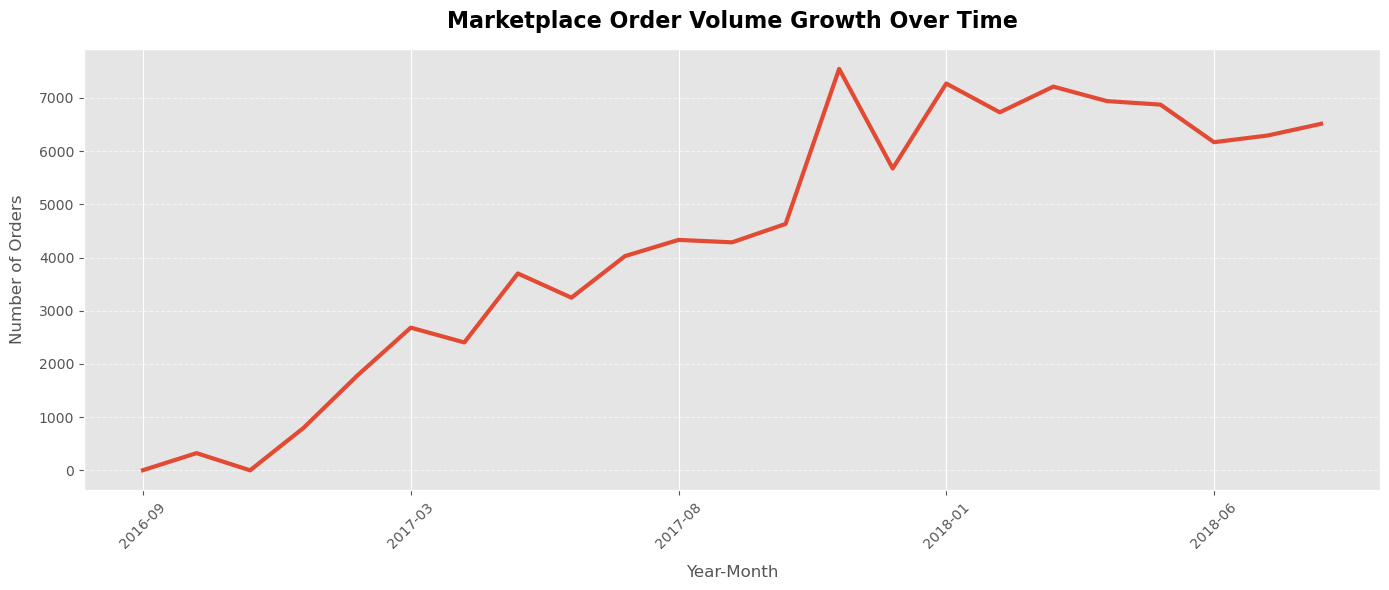

In [43]:
# Marketplace Order Volume Trend Analysis

plt.figure(figsize=(14,6))

monthly_orders_cleaned.plot(
    linewidth=3
)

plt.title(
    "Marketplace Order Volume Growth Over Time",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Year-Month",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Number of Orders",
    fontsize=12,
    labelpad=10
)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

### Business Insights — Order Growth Trends

- The marketplace experienced strong and consistent order growth during 2017 and early 2018, indicating successful customer acquisition and platform expansion.
- Transaction activity accelerated significantly over time, suggesting increasing marketplace adoption and operational scalability.
- A visible decline in the final months likely reflects incomplete dataset coverage rather than an actual business downturn.
- Sustained order growth indicates rising platform engagement and increasing transaction throughput.

## **Revenue Trend Analysis**

### Monthly Revenue Analysis

To analyze marketplace growth and overall business performance, monthly revenue trends were calculated using customer payment transactions.

Order and payment datasets were merged using the order ID to evaluate revenue generated over time.

This analysis helps identify:
- Revenue growth patterns
- Seasonal purchasing trends
- Business expansion over time
- Customer transaction behavior

In [14]:
incomplete_months = ['2018-09','2018-10']

In [15]:
orders_cleaned = orders[
    ~orders['year_month'].astype(str).isin(incomplete_months)
    ]

In [16]:
orders_cleaned.shape

(99421, 11)

In [17]:
orders_payments_cleaned = orders_cleaned.merge(
    payments,
    on='order_id',
    how='inner'
)

In [18]:
monthly_revenue_cleaned = (
    orders_payments_cleaned
    .groupby('year_month')['payment_value']
    .sum()
)

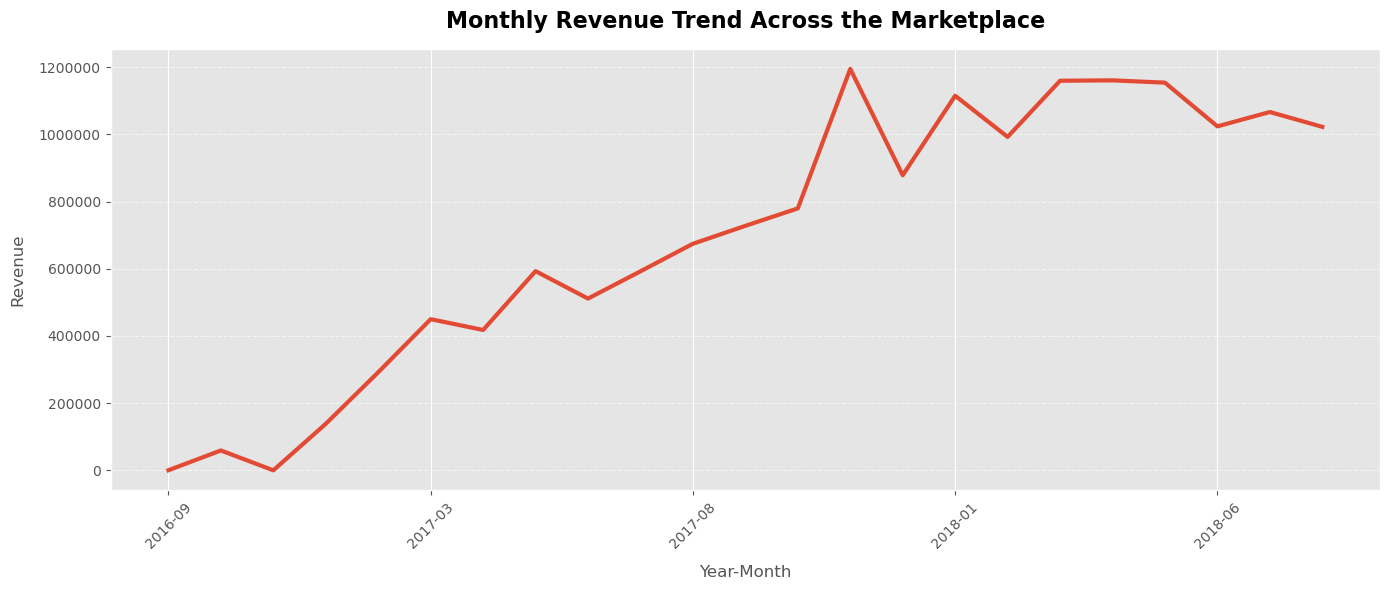

In [44]:
# Monthly Revenue Trend Analysis

plt.figure(figsize=(14,6))

monthly_revenue_cleaned.plot(
    linewidth=3
)

plt.title(
    "Monthly Revenue Trend Across the Marketplace",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Year-Month",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Revenue",
    fontsize=12,
    labelpad=10
)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

### Revenue Trend Insights

- Monthly revenue demonstrated strong growth throughout the observed period.
- Revenue trends aligned closely with increasing customer order activity.
- Significant business expansion was visible during 2017 and 2018.
- Seasonal fluctuations in customer purchasing behavior were observed across certain months.

## **Payment Method Analysis**

### Payment Type Distribution

To understand customer transaction preferences, payment method usage across all orders was analyzed.

This analysis helps identify:
- Preferred payment methods
- Customer purchasing behavior
- Transaction convenience trends
- Payment system adoption patterns

In [20]:
payment_type_counts = payments['payment_type'].value_counts()

In [21]:
payment_type_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

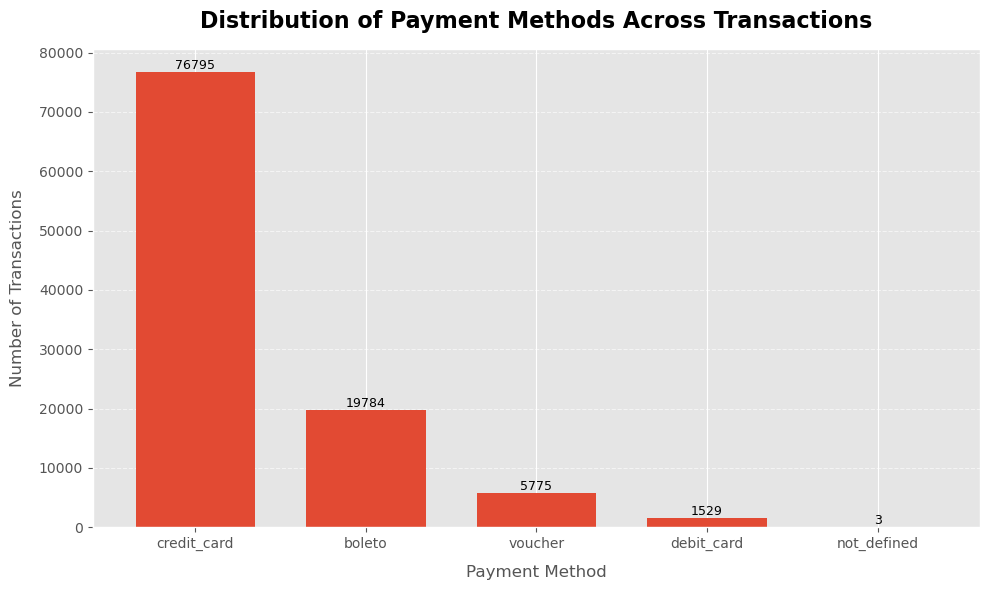

In [45]:
# Customer Payment Method Analysis

plt.figure(figsize=(10,6))

payment_type_counts.plot(
    kind='bar',
    width=0.7
)

plt.title(
    "Distribution of Payment Methods Across Transactions",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Payment Method",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Number of Transactions",
    fontsize=12,
    labelpad=10
)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top of bars
for index, value in enumerate(payment_type_counts.values):
    plt.text(
        index,
        value,
        str(value),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

plt.show()

### Business Insights — Customer Payment Preferences

- Credit cards dominate transaction activity, indicating strong customer preference for flexible digital payment methods.
- Voucher and debit-card usage remains comparatively low, suggesting limited dependency on alternative payment channels.
- Heavy concentration in credit-card transactions may increase exposure to installment-related financial risk and transaction processing costs.
- Payment behavior insights can help optimize promotional strategies, financing offers, and payment gateway partnerships.

## **Installment Usage Analysis**

### Installment Payment Distribution

To understand customer financing behavior, installment payment usage across transactions was analyzed.

This analysis helps identify:
- Customer preference for installment-based payments
- Financing adoption trends
- Short-term vs long-term installment usage
- Payment flexibility behavior among customers

In [23]:
installments_counts = payments['payment_installments'].value_counts().sort_index()

In [24]:
installments_counts.head(15)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
Name: count, dtype: int64

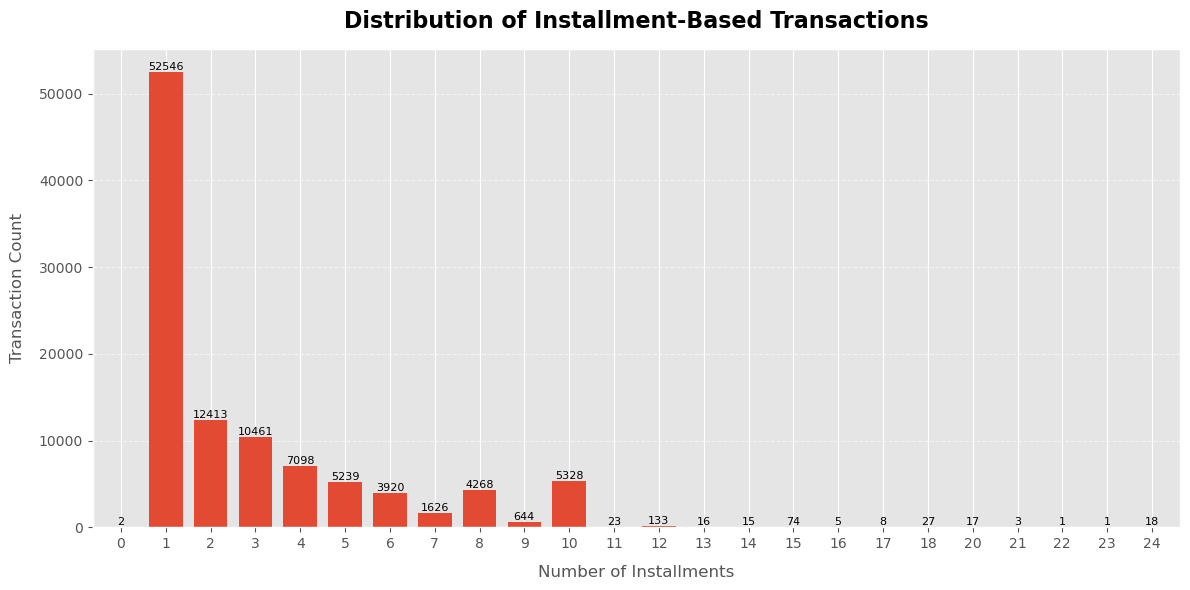

In [46]:
# Installment Payment Distribution Analysis

plt.figure(figsize=(12,6))

installments_counts.plot(
    kind='bar',
    width=0.75
)

plt.title(
    "Distribution of Installment-Based Transactions",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Number of Installments",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Transaction Count",
    fontsize=12,
    labelpad=10
)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add transaction count labels on bars
for index, value in enumerate(installments_counts.values):
    plt.text(
        index,
        value,
        str(value),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.show()

### Business Insights — Installment Behaviour

- Most customers prefer single-payment transactions, indicating lower financing dependency for the majority of purchases.
- Short installment plans between 2–4 payments remain widely adopted, balancing affordability and financial flexibility.
- Long-duration installment plans are relatively uncommon, suggesting cautious customer borrowing behavior.
- Elevated usage around 10-installment plans may indicate targeted promotional financing strategies or category-specific purchasing behavior.
- Installment analysis can support financial planning, payment strategy optimization, and customer affordability segmentation.

## **Product Category Revenue Analysis**

### Product Category Performance Analysis

Product and translation datasets were merged to map Portuguese category names into English for improved interpretability.

The analysis focuses on identifying the highest revenue-generating product categories across the marketplace.

This helps understand:
- Top-performing product segments
- Revenue contribution by category
- Customer purchasing preferences
- Business growth opportunities

In [26]:
product_translated = products.merge (
    translation,
    on='product_category_name',
    how='left'
)   

In [27]:
order_products = order_items.merge (
    product_translated,
    on='product_id',
    how='left'
)

In [28]:
category_revenue = (
    order_products
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
)

In [29]:
top_10_categories = category_revenue.head(10)

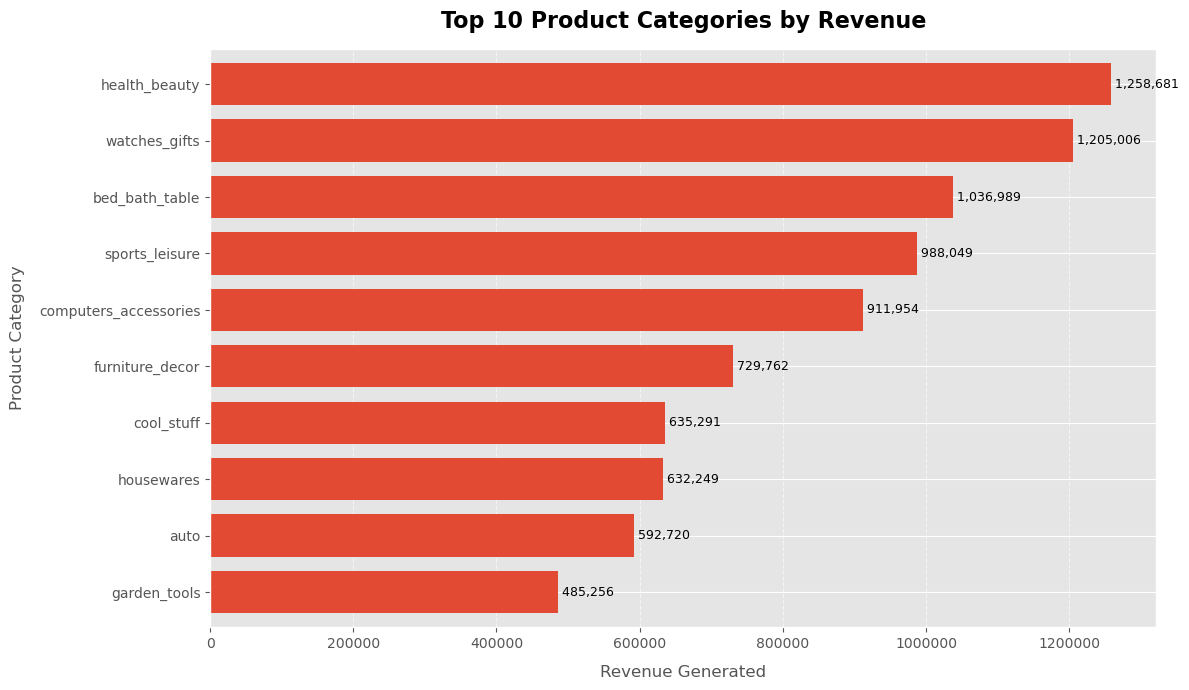

In [47]:
# Top Product Categories by Revenue

plt.figure(figsize=(12,7))

top_10_categories.sort_values().plot(
    kind='barh',
    width=0.75
)

plt.title(
    "Top 10 Product Categories by Revenue",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Revenue Generated",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Product Category",
    fontsize=12,
    labelpad=10
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ticklabel_format(style='plain', axis='x')

plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add revenue labels beside bars
for index, value in enumerate(top_10_categories.sort_values().values):
    plt.text(
        value,
        index,
        f' {value:,.0f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()

plt.show()

### Product Category Performance Insights

- A small number of product categories contribute significantly to total marketplace revenue.
- Categories related to home, electronics, and lifestyle products showed strong performance.
- Revenue concentration indicates high customer demand in specific product segments.
- Top-performing categories may represent strategic growth opportunities for the business.

## **Regional Revenue Analysis**

### Top States by Revenue

To analyze geographical business performance, customer and order datasets were merged to identify the highest revenue-generating states.

This analysis helps understand:
- Regional sales distribution
- High-performing markets
- Customer concentration across states
- Geographic business expansion opportunities

In [31]:
customer_orders = orders_cleaned.merge (
    customers,
    on='customer_id',
    how='left'
)

In [32]:
customer_revenue = customer_orders.merge (
    payments,
    on='order_id',
    how='left'
)

In [33]:
state_revenue = (
    customer_revenue
    .groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

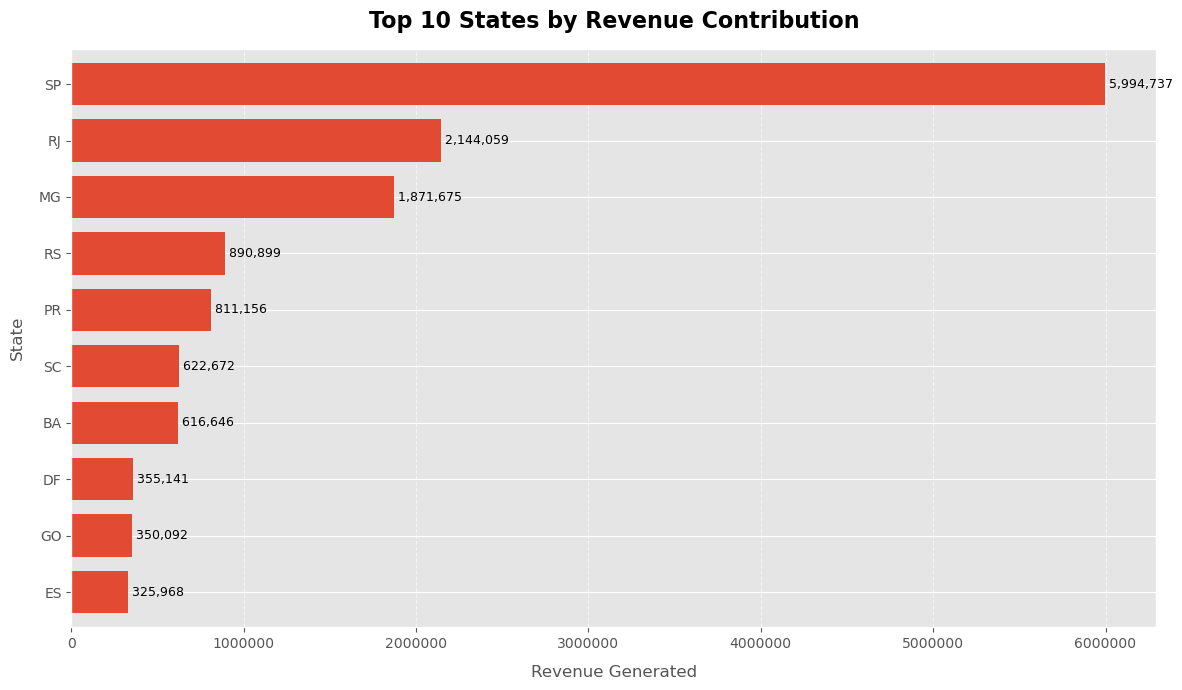

In [48]:
# Top Revenue-Generating States Analysis

plt.figure(figsize=(12,7))

state_revenue.head(10).sort_values().plot(
    kind='barh',
    width=0.75
)

plt.title(
    "Top 10 States by Revenue Contribution",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Revenue Generated",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "State",
    fontsize=12,
    labelpad=10
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ticklabel_format(style='plain', axis='x')

plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add revenue labels beside bars
for index, value in enumerate(state_revenue.head(10).sort_values().values):
    plt.text(
        value,
        index,
        f' {value:,.0f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()

plt.show()

### Top States Revenue Insights

- A few states contribute a major share of total marketplace revenue.
- São Paulo (SP) emerged as the strongest revenue-generating state.
- Revenue distribution indicates high customer concentration in urban and economically active regions.
- Regional performance analysis can support targeted business expansion and marketing strategies.

## **Delivery Time Analysis**

### Delivery Time Distribution

To evaluate logistics performance and customer delivery experience, delivery duration was calculated using order purchase and delivery dates.

This analysis helps identify:
- Typical delivery timelines
- Delivery consistency
- Delayed shipment patterns
- Overall fulfillment efficiency

In [35]:
orders_cleaned.loc[:, 'delivery_days'] = (
    orders_cleaned['order_delivered_customer_date']
    - orders_cleaned['order_purchase_timestamp']
).dt.days

C:\Users\tejee\AppData\Local\Temp\ipykernel_5868\2806789344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_cleaned.loc[:, 'delivery_days'] = (


In [36]:
orders_cleaned[['delivery_days']].head()

,delivery_days
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0


In [37]:
orders_cleaned['delivery_days'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

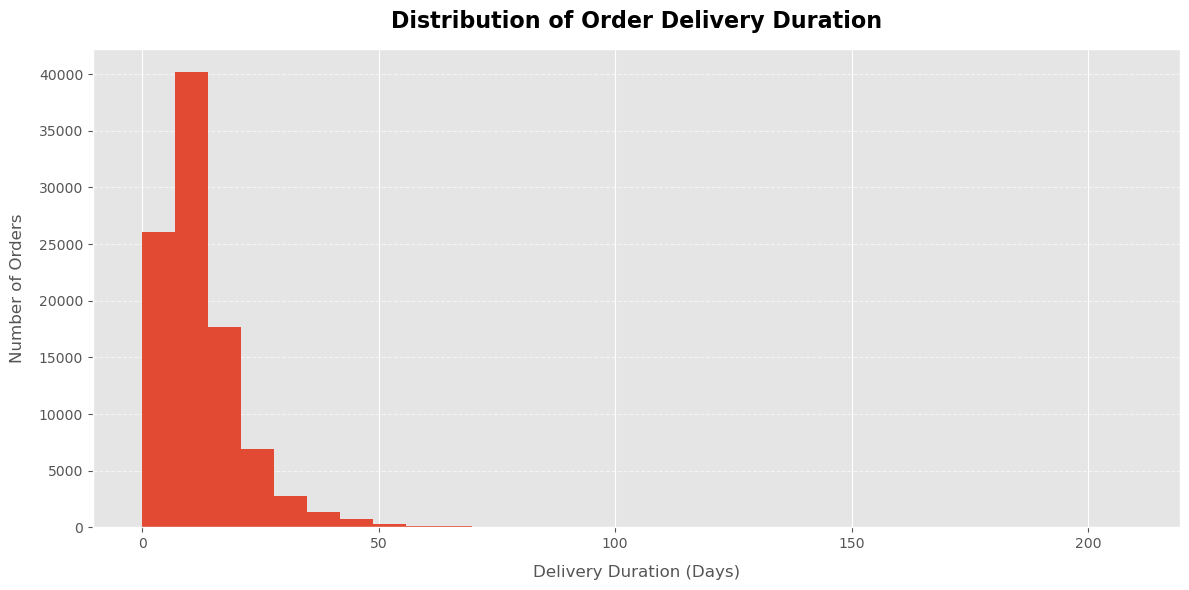

In [49]:
# Delivery Time Distribution Analysis

plt.figure(figsize=(12,6))

orders_cleaned['delivery_days'].hist(
    bins=30
)

plt.title(
    "Distribution of Order Delivery Duration",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Delivery Duration (Days)",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Number of Orders",
    fontsize=12,
    labelpad=10
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

### Delivery Performance Insights

- Most orders are delivered withthin 5-20 days.
- The Delivery distribution is right-skewed, indicating some delayed deliveries.
- A small number of orders took significantly longer to reach customers.
- Overall delivery performance appears relatively stable for the majority of the customers.

## **Late Delivery Analysis**

### Late Delivery Distribution

To evaluate delivery reliability, actual delivery dates were compared against estimated delivery dates provided to customers.

This analysis helps understand:
- Delivery punctuality
- Early vs delayed deliveries
- Logistics reliability
- Customer fulfillment performance

In [39]:
orders_cleaned.loc[:,'late_delivery_days'] = (
    orders_cleaned['order_delivered_customer_date']
    - orders_cleaned['order_estimated_delivery_date']
).dt.days

C:\Users\tejee\AppData\Local\Temp\ipykernel_5868\1813844616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_cleaned.loc[:,'late_delivery_days'] = (


In [40]:
orders_cleaned[['late_delivery_days']].head()

,late_delivery_days
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


In [41]:
orders_cleaned['late_delivery_days'].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: late_delivery_days, dtype: float64

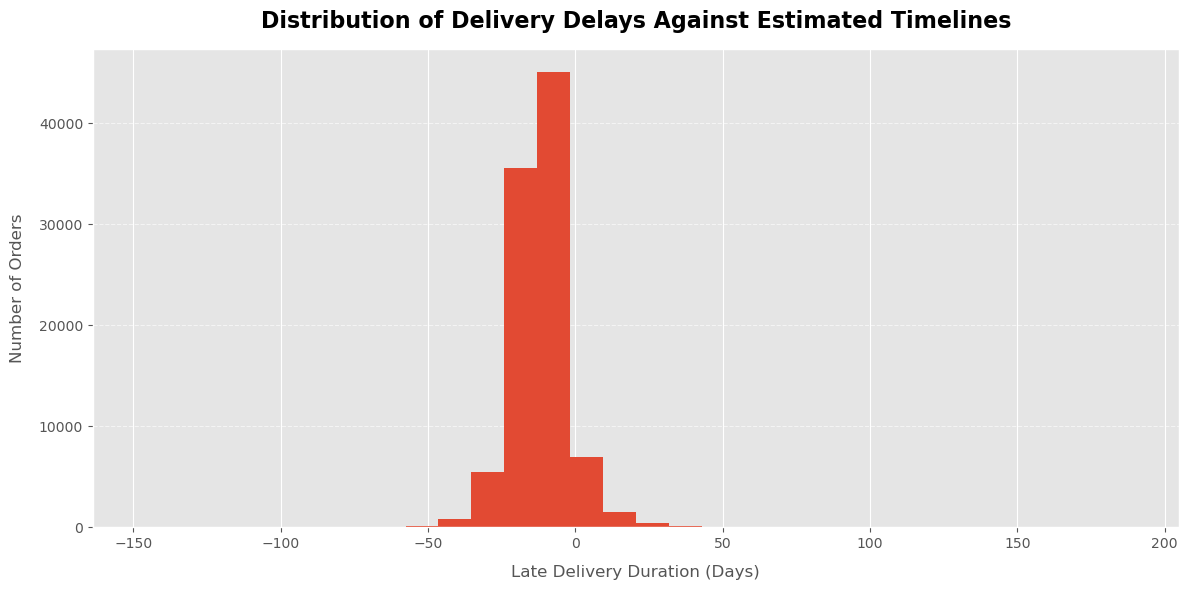

In [50]:
# Late Delivery Distribution Analysis

plt.figure(figsize=(12,6))

orders_cleaned['late_delivery_days'].hist(
    bins=30
)

plt.title(
    "Distribution of Delivery Delays Against Estimated Timelines",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Late Delivery Duration (Days)",
    fontsize=12,
    labelpad=10
)

plt.ylabel(
    "Number of Orders",
    fontsize=12,
    labelpad=10
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

### Late Delivery Insights

- Most orders were delivered before the estimated delivery date.
- The distribution is concentrated on the negative side, indicating early deliveries.
- Only a smaller percentage of orders experienced delivery delays.
- Overall logistics performance appears reliable and customer-friendly.

## **Final Conclusion**

## Project Summary

This end-to-end e-commerce analytics project explored customer behavior, sales performance, payment trends, logistics efficiency, and customer segmentation using the Olist marketplace dataset.

Key areas analyzed include:
- Monthly order and revenue trends
- Payment method and installment behavior
- Product category performance
- Regional revenue distribution
- Delivery and late shipment analysis

The project combined:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Business KPI analysis
- Data visualization
- Customer analytics techniques

This analysis demonstrates how data-driven insights can support:
- Business decision-making
- Customer retention strategies
- Revenue optimization
- Logistics improvement
- Market expansion planning

## Future Enhancements

Potential future improvements include:
- Predictive modeling for customer churn
- Customer Lifetime Value (CLV) estimation
- Sales forecasting
- Machine Learning-based customer clustering